In [2]:
"""
ml_training/models/xgboost/trainer.py
Train XGBoost phân loại AQI + tối ưu Optuna + phân tích SHAP.
"""
import numpy as np
import pandas as pd
import joblib, os, json
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import optuna
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

EXPORT_DIR  = "../data/exports"
MODEL_DIR   = "../../models/xgboost"
os.makedirs(MODEL_DIR, exist_ok=True)

c:\Users\Acer\Desktop\DATN\DATN_AIR_GROARD_BN_2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ── Load dữ liệu đã split ────────────────────────────────────────────────────
from sys import path
path.insert(0, "../preprocessing")
from data_loader import (load_and_prepare, temporal_split,
                            build_xgb_data, XGB_FEATURES)

print("="*55)
print("PIPELINE A — XGBoost + SHAP")
print("="*55)

df, le        = load_and_prepare()
train, val, test = temporal_split(df)

X_tr, X_vl, X_te, y_tr, y_vl, y_te = build_xgb_data(train, val, test)
feat_names = joblib.load(f"{EXPORT_DIR}/xgb_feature_names.pkl")

# ── Tính class weight để xử lý imbalanced ────────────────────────────────────
classes = np.unique(y_tr)
weights = compute_class_weight("balanced", classes=classes, y=y_tr)
w_dict  = dict(zip(classes.tolist(), weights.tolist()))
sample_weights = np.array([w_dict[y] for y in y_tr])

print(f"\nClass weights (balanced):")
for cls_id, w in w_dict.items():
    print(f"  [{le.classes_[cls_id]}] weight={w:.3f}")


PIPELINE A — XGBoost + SHAP
Đang tải dataset...
Dataset sau xử lý: 546,601 records
Phân phối AQI:
aqi_level
Trung bình        231865
Kém (nhạy cảm)    194872
Tốt                74681
Kém                25946
Nguy hại           14098
Rất xấu             5139
Name: count, dtype: int64

Train : 382,620 records (2022-08-06 → 2025-03-01)
Val   : 81,990 records (2025-03-01 → 2025-09-18)
Test  : 81,991 records (2025-09-18 → 2026-04-06)

XGBoost: 48 features

Class weights (balanced):
  [Tốt] weight=1.033
  [Trung bình] weight=0.385
  [Kém (nhạy cảm)] weight=0.507
  [Kém] weight=3.743
  [Rất xấu] weight=19.847
  [Nguy hại] weight=6.824


In [4]:
# ── Bước 1: Baseline nhanh (không tune) ──────────────────────────────────────
print("\n[1/3] Train baseline XGBoost...")
baseline = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
)
baseline.fit(
    X_tr, y_tr,
    sample_weight=sample_weights,
    eval_set=[(X_vl, y_vl)],
    verbose=False,
)
y_pred_base = baseline.predict(X_vl)
f1_base = f1_score(y_vl, y_pred_base, average="weighted")
print(f"  Val F1 (weighted): {f1_base:.4f}")


[1/3] Train baseline XGBoost...
  Val F1 (weighted): 0.9974


In [5]:
# ── Bước 2: Optuna hyperparameter tuning ─────────────────────────────────────
print("\n[2/3] Optuna tuning (50 trials)...")

def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 800),
        "max_depth":         trial.suggest_int("max_depth", 4, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 0, 5),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0.5, 5),
    }
    model = xgb.XGBClassifier(
        **params,
        use_label_encoder=False,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_tr, y_tr,
              sample_weight=sample_weights,
              eval_set=[(X_vl, y_vl)],
              verbose=False)
    y_pred = model.predict(X_vl)
    return f1_score(y_vl, y_pred, average="weighted")
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
print(f"\n  Best F1 (val): {study.best_value:.4f}")
print(f"  Best params  : {best_params}")



[2/3] Optuna tuning (50 trials)...


Best trial: 26. Best value: 0.998391: 100%|██████████| 50/50 [46:24<00:00, 55.69s/it]


  Best F1 (val): 0.9984
  Best params  : {'n_estimators': 660, 'max_depth': 9, 'learning_rate': 0.06113286688674585, 'subsample': 0.6083727754776589, 'colsample_bytree': 0.8785179809330729, 'min_child_weight': 3, 'gamma': 4.9972840984288265, 'reg_alpha': 0.1119990177416148, 'reg_lambda': 1.827827405441941}


In [6]:
# ── Bước 3: Train model tốt nhất ─────────────────────────────────────────────
print("\n[3/3] Train model tốt nhất...")
best_model = xgb.XGBClassifier(
    **best_params,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
)
best_model.fit(
    X_tr, y_tr,
    sample_weight=sample_weights,
    eval_set=[(X_vl, y_vl)],
    verbose=False,
)



[3/3] Train model tốt nhất...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8785179809330729
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import l

In [7]:
# ── Đánh giá trên Test set ────────────────────────────────────────────────────
y_pred_test = best_model.predict(X_te)
acc  = accuracy_score(y_te, y_pred_test)
f1   = f1_score(y_te, y_pred_test, average="weighted")

print(f"\n{'='*55}")
print(f"KẾT QUẢ TEST SET")
print(f"{'='*55}")
print(f"Accuracy (weighted): {acc:.4f}")
print(f"F1-score (weighted): {f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_te, y_pred_test,
                             target_names=le.classes_))


KẾT QUẢ TEST SET
Accuracy (weighted): 0.9982
F1-score (weighted): 0.9982

Classification Report:
                precision    recall  f1-score   support

           Tốt       1.00      1.00      1.00     10187
    Trung bình       1.00      1.00      1.00     35792
Kém (nhạy cảm)       1.00      1.00      1.00     32404
           Kém       1.00      0.94      0.97      1309
       Rất xấu       1.00      1.00      1.00       250
      Nguy hại       1.00      1.00      1.00      2049

      accuracy                           1.00     81991
     macro avg       1.00      0.99      0.99     81991
  weighted avg       1.00      1.00      1.00     81991



In [8]:
# ── SHAP Analysis ─────────────────────────────────────────────────────────────
print("\nTính SHAP values...")
explainer    = shap.TreeExplainer(best_model)
# Dùng 2000 mẫu đại diện để tính nhanh hơn
sample_idx   = np.random.choice(len(X_te), 2000, replace=False)
shap_values  = explainer.shap_values(X_te[sample_idx])


Tính SHAP values...


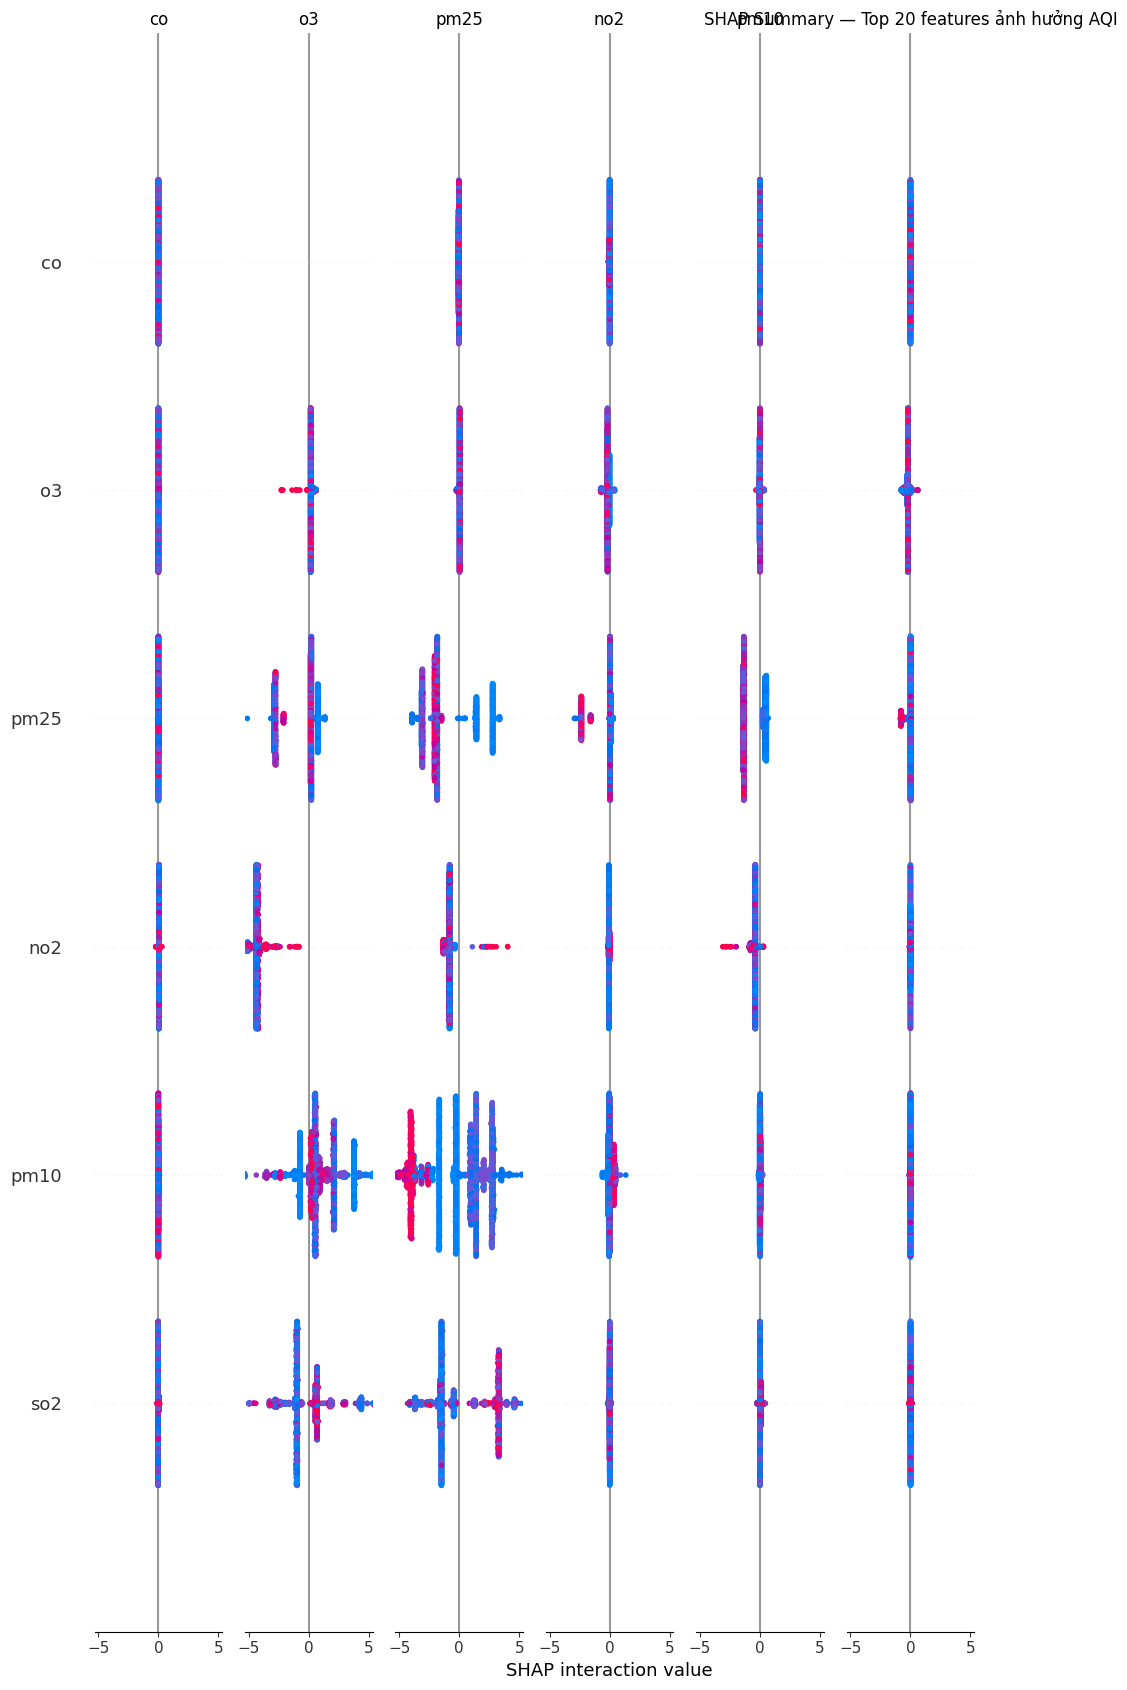

  Lưu: ../../models/xgboost/shap_summary.png


In [9]:
# Summary plot — top 20 features quan trọng nhất
shap.summary_plot(
    shap_values, X_te[sample_idx],
    feature_names=feat_names,
    max_display=20,
    show=False
)
plt.title("SHAP Summary — Top 20 features ảnh hưởng AQI")
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  Lưu: {MODEL_DIR}/shap_summary.png")

In [10]:
# Feature importance từ XGBoost
fi = pd.DataFrame({
    "feature":    feat_names,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)
print(f"\nTop 15 features quan trọng nhất:")
print(fi.head(15).to_string(index=False))


Top 15 features quan trọng nhất:
    feature  importance
 aqi_roll3h    0.320292
         o3    0.175344
     aqi_o3    0.118312
   aqi_pm25    0.077137
  aqi_lag1h    0.059199
       pm25    0.035782
 aqi_roll6h    0.033437
   aqi_pm10    0.022625
    aqi_no2    0.020880
    aqi_so2    0.020282
        so2    0.009343
  aqi_lag3h    0.008959
        no2    0.008627
pm25_roll3h    0.006852
   hour_sin    0.006732


In [11]:
# ── Lưu model và artifacts ────────────────────────────────────────────────────
joblib.dump(best_model, f"{MODEL_DIR}/model.pkl")
joblib.dump(explainer,  f"{MODEL_DIR}/shap_explainer.pkl")

metadata = {
    "model_type":    "XGBoostClassifier",
    "n_features":    len(feat_names),
    "feature_names": feat_names,
    "classes":       le.classes_.tolist(),
    "best_params":   best_params,
    "metrics": {
        "val_f1_baseline": round(f1_base, 4),
        "val_f1_tuned":    round(study.best_value, 4),
        "test_accuracy":   round(acc, 4),
        "test_f1":         round(f1, 4),
    },
    "optuna_n_trials": 50,
}
with open(f"{MODEL_DIR}/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"\nModel lưu tại: {MODEL_DIR}/")
print(f"  model.pkl            — XGBoost model")
print(f"  shap_explainer.pkl   — SHAP TreeExplainer")
print(f"  metadata.json        — Thông tin model + metrics")
print(f"  shap_summary.png     — Biểu đồ SHAP")


Model lưu tại: ../../models/xgboost/
  model.pkl            — XGBoost model
  shap_explainer.pkl   — SHAP TreeExplainer
  metadata.json        — Thông tin model + metrics
  shap_summary.png     — Biểu đồ SHAP
